In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# anchor to repo root by walking up to pyproject.toml — works regardless of kernel CWD
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA = ROOT / "data" / "raw"

txn = pd.read_csv(DATA / "train_transaction.csv")
idn = pd.read_csv(DATA / "train_identity.csv")

print("transactions:", txn.shape)   # ~ (590540, 394)
print("identity:    ", idn.shape)   # ~ (144233,  41)

df = txn.merge(idn, on="TransactionID", how="left")
print("merged:      ", df.shape)
print("row count preserved:", df.shape[0] == txn.shape[0])


transactions: (590540, 394)
identity:     (144233, 41)
merged:       (590540, 434)
row count preserved: True


In [2]:
counts = df["isFraud"].value_counts()
rate   = df["isFraud"].mean()

print(counts)
print(f"\nfraud rate: {rate:.4%}")
print(f"legit : fraud  ≈  {counts[0] // counts[1]} : 1")


isFraud
0    569877
1     20663
Name: count, dtype: int64

fraud rate: 3.4990%
legit : fraud  ≈  27 : 1


In [3]:
# Target: the answer key
y = df["isFraud"]

# Features: NUMERIC columns only, for now.
# We drop the identifier and the label itself.
X = df.select_dtypes(include=[np.number]).drop(columns=["isFraud", "TransactionID"])

print("feature matrix:", X.shape)
print("dropped (non-numeric) columns:", df.shape[1] - X.shape[1] - 0)
print("fraction of X that is missing:", X.isna().mean().mean().round(3))


feature matrix: (590540, 401)
dropped (non-numeric) columns: 33
fraction of X that is missing: 0.44


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("train fraud rate:", y_train.mean().round(4))
print("test  fraud rate:", y_test.mean().round(4))   # should match train


train fraud rate: 0.035
test  fraud rate: 0.035


In [5]:
from xgboost import XGBClassifier

model = XGBClassifier(
    tree_method="hist",   # fast histogram algorithm; fine for 590k rows
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
    # NOTE: no scale_pos_weight, no class weighting, nothing for imbalance.
)

model.fit(X_train, y_train)
print("trained:", model.n_estimators, "trees")


trained: None trees


In [6]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, roc_auc_score, average_precision_score,
)

proba = model.predict_proba(X_test)[:, 1]   # P(fraud)
pred  = (proba >= 0.5).astype(int)          # naive 0.5 threshold

dummy_acc = 1 - y_test.mean()   # accuracy of "predict legit for everyone"

print(f"Model accuracy      : {accuracy_score(y_test, pred):.4f}")
print(f"'Always legit' acc  : {dummy_acc:.4f}   <-- baseline that catches ZERO fraud\n")

print("Confusion matrix  [rows=actual, cols=predicted]")
print("            pred_legit  pred_fraud")
cm = confusion_matrix(y_test, pred)
print("actual_legit ", cm[0])
print("actual_fraud ", cm[1], "\n")

print(classification_report(y_test, pred, digits=4))

print(f"ROC-AUC : {roc_auc_score(y_test, proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, proba):.4f}   <-- the honest metric")


Model accuracy      : 0.9796
'Always legit' acc  : 0.9650   <-- baseline that catches ZERO fraud

Confusion matrix  [rows=actual, cols=predicted]
            pred_legit  pred_fraud
actual_legit  [113721    254]
actual_fraud  [2157 1976] 

              precision    recall  f1-score   support

           0     0.9814    0.9978    0.9895    113975
           1     0.8861    0.4781    0.6211      4133

    accuracy                         0.9796    118108
   macro avg     0.9337    0.7379    0.8053    118108
weighted avg     0.9781    0.9796    0.9766    118108

ROC-AUC : 0.9362
PR-AUC  : 0.6925   <-- the honest metric


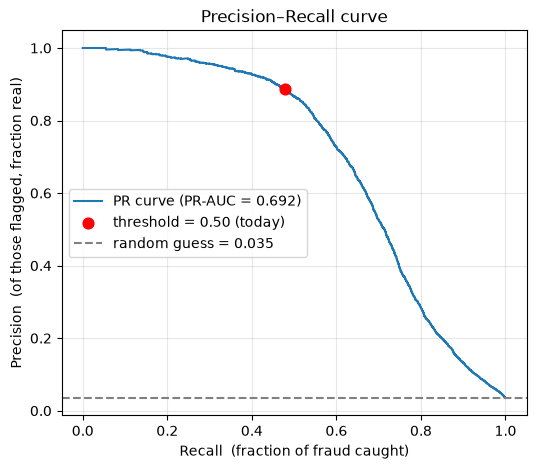

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score

prec, rec, thr = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

# where the default 0.5 threshold sits
p50 = precision_score(y_test, proba >= 0.5)
r50 = recall_score(y_test, proba >= 0.5)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"PR curve (PR-AUC = {ap:.3f})")
plt.scatter([r50], [p50], color="red", zorder=5, s=60, label="threshold = 0.50 (today)")
plt.axhline(y_test.mean(), ls="--", color="grey", label=f"random guess = {y_test.mean():.3f}")
plt.xlabel("Recall  (fraction of fraud caught)")
plt.ylabel("Precision  (of those flagged, fraction real)")
plt.title("Precision–Recall curve")
plt.legend(); plt.grid(alpha=0.3); plt.show()


In [8]:
import numpy as np, pandas as pd
from sklearn.metrics import confusion_matrix

rows = []
for t in [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]:
    tn, fp, fn, tp = confusion_matrix(y_test, proba >= t).ravel()
    rows.append([t, tp + fp, tp, fn, fp,
                 round(tp / (tp + fp), 3) if tp + fp else 0,
                 round(tp / (tp + fn), 3)])

cols = ["threshold", "flagged", "caught(TP)", "missed(FN)", "false_alarm(FP)", "precision", "recall"]
print(pd.DataFrame(rows, columns=cols).to_string(index=False))


 threshold  flagged  caught(TP)  missed(FN)  false_alarm(FP)  precision  recall
      0.05    10882        3273         860             7609      0.301   0.792
      0.10     5857        2942        1191             2915      0.502   0.712
      0.20     3619        2548        1585             1071      0.704   0.617
      0.30     2896        2305        1828              591      0.796   0.558
      0.50     2230        1976        2157              254      0.886   0.478
      0.70     1789        1658        2475              131      0.927   0.401
      0.90     1323        1264        2869               59      0.955   0.306


In [9]:
# Illustrative cost assumptions — these are business inputs you'd tune with the insurer.
COST_FN = 100.0   # missing a fraud  -> a full payout lost
COST_FP =   1.0   # a false alarm    -> an investigator's wasted time

thresholds = np.linspace(0.01, 0.99, 99)
costs = np.array([
    (lambda c: c[2] * COST_FN + c[1] * COST_FP)(confusion_matrix(y_test, proba >= t).ravel())
    for t in thresholds
])  # c = (tn, fp, fn, tp) -> fn*COST_FN + fp*COST_FP

best_t = thresholds[costs.argmin()]
print(f"cost-optimal threshold: {best_t:.2f}\n")

for label, t in [("0.50 default", 0.50), ("cost-optimal", best_t)]:
    tn, fp, fn, tp = confusion_matrix(y_test, proba >= t).ravel()
    total = fn * COST_FN + fp * COST_FP
    print(f"{label:13s} thr={t:.2f}  recall={tp/(tp+fn):.3f}  precision={tp/(tp+fp):.3f}  "
          f"missed={fn:5d}  false_alarms={fp:5d}  total_cost={total:,.0f}")


cost-optimal threshold: 0.01

0.50 default  thr=0.50  recall=0.478  precision=0.886  missed= 2157  false_alarms=  254  total_cost=215,954
cost-optimal  thr=0.01  recall=0.948  precision=0.084  missed=  216  false_alarms=42846  total_cost=64,446
